# Simulation appendix: stochastic volatility processes

This notebook provides a computational illustration for the thesis appendix on Bayesian inference in stochastic volatility (SV) models for financial returns. The goal is not to estimate an empirical market series, but to show how a persistent latent volatility state can produce the stylized facts that motivate SV models: volatility clustering, weak serial correlation in raw returns, and stronger serial dependence in absolute or squared returns.

The first part follows the appendix draft exactly. The final part adds a simple known-parameter particle filter to illustrate the Bayesian latent-state inference problem: returns are observed, but the log-volatility path is hidden and must be inferred probabilistically.

In [1]:
from pathlib import Path
import os
import tempfile

# Keep Matplotlib cache outside the repository and avoid local permission warnings.
MPLCONFIGDIR = Path(tempfile.gettempdir()) / "matplotlib-cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import numpy as np
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures/sv_simulation")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved: {path}")
    return path

## 1. Model specification

The simulated discrete-time stochastic volatility model is

$$
h_t = \mu + \phi(h_{t-1} - \mu) + \eta_t, \qquad \eta_t \sim N(0, \sigma_\eta^2),
$$

$$
r_t = \exp(h_t/2)\varepsilon_t, \qquad \varepsilon_t \sim N(0, 1).
$$

Here $h_t$ is latent log-volatility and $\exp(h_t/2)$ is the conditional standard deviation of returns. The baseline values match the appendix draft: $T=1000$, $\mu=-0.5$, $\phi=0.98$, and $\sigma_\eta=0.15$. Since $|\phi|<1$, the stationary initialization is

$$
h_1 \sim N\left(\mu, \frac{\sigma_\eta^2}{1-\phi^2}\right).
$$

In [2]:
def simulate_sv(T=1000, mu=-0.5, phi=0.98, sigma_eta=0.15, seed=123):
    """Simulate returns and latent log-volatility from the basic SV model."""
    if not -1 < phi < 1:
        raise ValueError("Stationary initialization requires |phi| < 1.")

    rng = np.random.default_rng(seed)
    h = np.empty(T)
    eta = np.empty(T)

    stationary_sd = sigma_eta / np.sqrt(1 - phi**2)
    h[0] = rng.normal(mu, stationary_sd)
    eta[0] = h[0] - mu

    for t in range(1, T):
        eta[t] = rng.normal(0, sigma_eta)
        h[t] = mu + phi * (h[t - 1] - mu) + eta[t]

    epsilon = rng.normal(0, 1, T)
    sigma = np.exp(h / 2)
    r = sigma * epsilon

    return {
        "time": np.arange(1, T + 1),
        "h": h,
        "sigma": sigma,
        "r": r,
        "epsilon": epsilon,
        "eta": eta,
        "params": {
            "T": T,
            "mu": mu,
            "phi": phi,
            "sigma_eta": sigma_eta,
            "seed": seed,
            "stationary_sd_h": stationary_sd,
        },
    }


baseline = simulate_sv()
baseline["params"]

{'T': 1000,
 'mu': -0.5,
 'phi': 0.98,
 'sigma_eta': 0.15,
 'seed': 123,
 'stationary_sd_h': np.float64(0.7537783614444082)}

## 2. One simulated SV path

The latent process is persistent because $\phi$ is close to one. High values of $h_t$ raise the conditional standard deviation, so the return series displays bursts of large movements even though the standardized innovations $\varepsilon_t$ are independent Gaussian shocks.

<>:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_27809/1471405759.py:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  axes[1].set_ylabel("$\exp(h_t/2)$")


saved: figures/sv_simulation/baseline_sv_paths.png


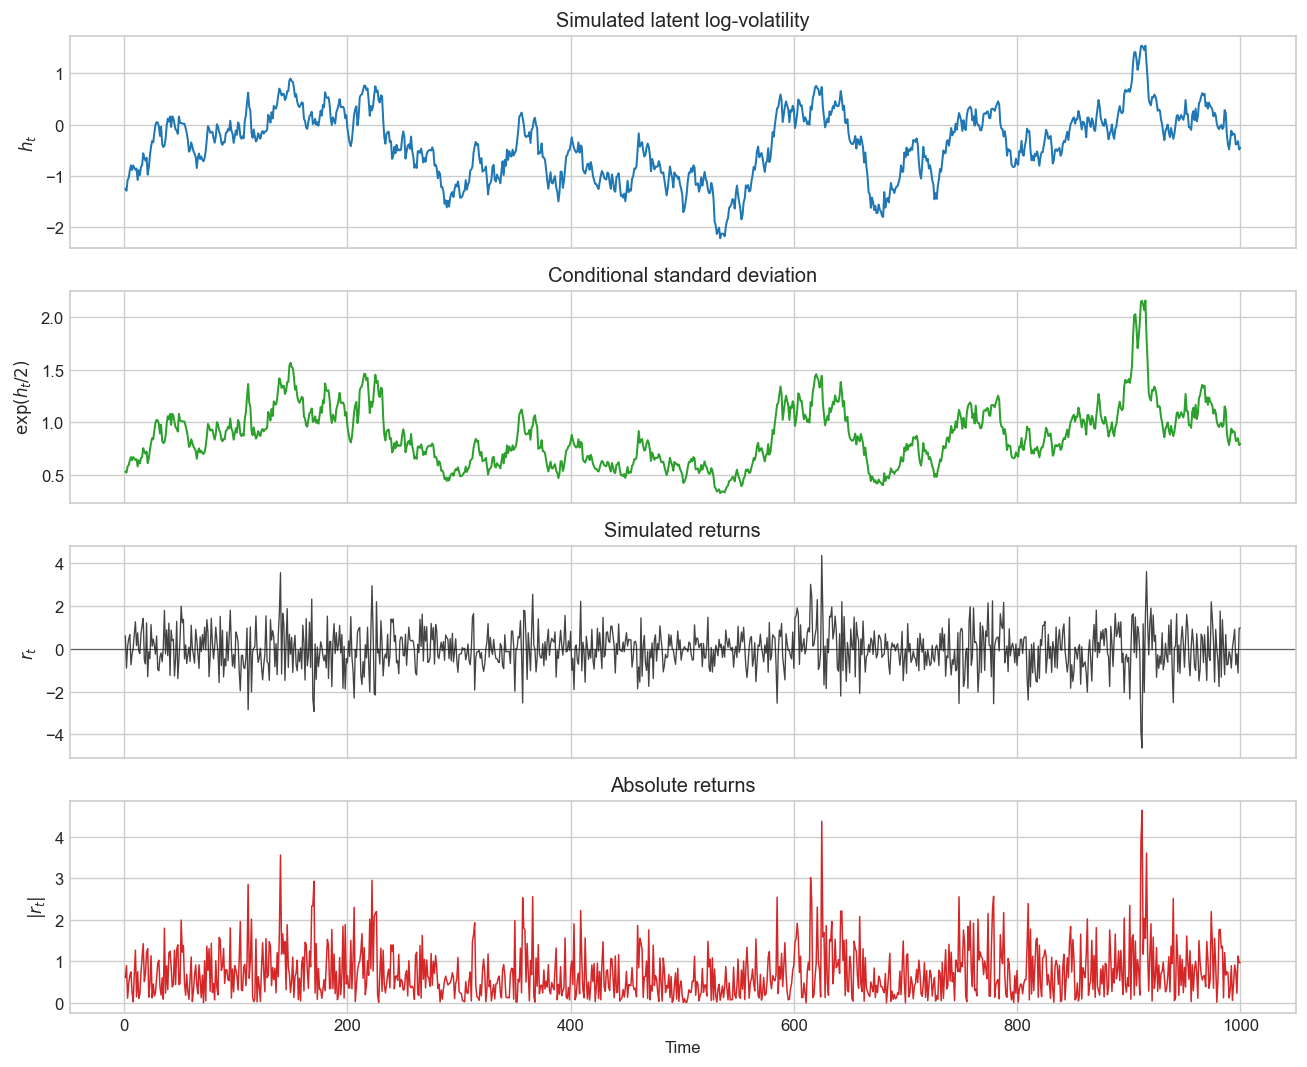

saved: figures/sv_simulation/latent_log_volatility.png
saved: figures/sv_simulation/conditional_standard_deviation.png
saved: figures/sv_simulation/simulated_returns.png
saved: figures/sv_simulation/absolute_returns.png


In [3]:
time = baseline["time"]
h = baseline["h"]
sigma = baseline["sigma"]
r = baseline["r"]

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

axes[0].plot(time, h, color="#1f77b4", linewidth=1.2)
axes[0].set_title("Simulated latent log-volatility")
axes[0].set_ylabel("$h_t$")

axes[1].plot(time, sigma, color="#2ca02c", linewidth=1.2)
axes[1].set_title("Conditional standard deviation")
axes[1].set_ylabel("$\exp(h_t/2)$")

axes[2].plot(time, r, color="#444444", linewidth=0.8)
axes[2].axhline(0, color="#111111", linewidth=0.7, alpha=0.6)
axes[2].set_title("Simulated returns")
axes[2].set_ylabel("$r_t$")

axes[3].plot(time, np.abs(r), color="#d62728", linewidth=0.9)
axes[3].set_title("Absolute returns")
axes[3].set_ylabel("$|r_t|$")
axes[3].set_xlabel("Time")

fig.tight_layout()
save_figure(fig, "baseline_sv_paths.png")
plt.show()

# Save separate figures with names that can be used directly in the LaTeX appendix.
single_series = [
    (h, "Simulated latent log-volatility", "$h_t$", "latent_log_volatility.png", "#1f77b4"),
    (sigma, "Simulated conditional standard deviation", "$\\exp(h_t/2)$", "conditional_standard_deviation.png", "#2ca02c"),
    (r, "Simulated returns from the SV model", "$r_t$", "simulated_returns.png", "#444444"),
    (np.abs(r), "Absolute returns", "$|r_t|$", "absolute_returns.png", "#d62728"),
]

for y, title, ylabel, filename, color in single_series:
    fig_single, ax = plt.subplots(figsize=(10, 4))
    ax.plot(time, y, color=color, linewidth=1.0)
    if filename == "simulated_returns.png":
        ax.axhline(0, color="#111111", linewidth=0.7, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    fig_single.tight_layout()
    save_figure(fig_single, filename)
    plt.close(fig_single)

## 3. Diagnostics: stylized facts generated by the SV model

A useful appendix figure should show more than the path itself. The diagnostics below summarize the mechanism: the raw returns have little serial correlation, while absolute and squared returns retain serial dependence because the hidden volatility state is persistent.

Baseline simulation diagnostics
------------------------------------
mean(r_t)                      -0.0009
std(r_t)                        0.9468
Pearson kurtosis of r_t         4.4670
corr(r_t, r_{t-1})              0.0266
corr(|r_t|, |r_{t-1}|)          0.1287
corr(r_t^2, r_{t-1}^2)          0.1979
saved: figures/sv_simulation/acf_returns_abs_squared.png


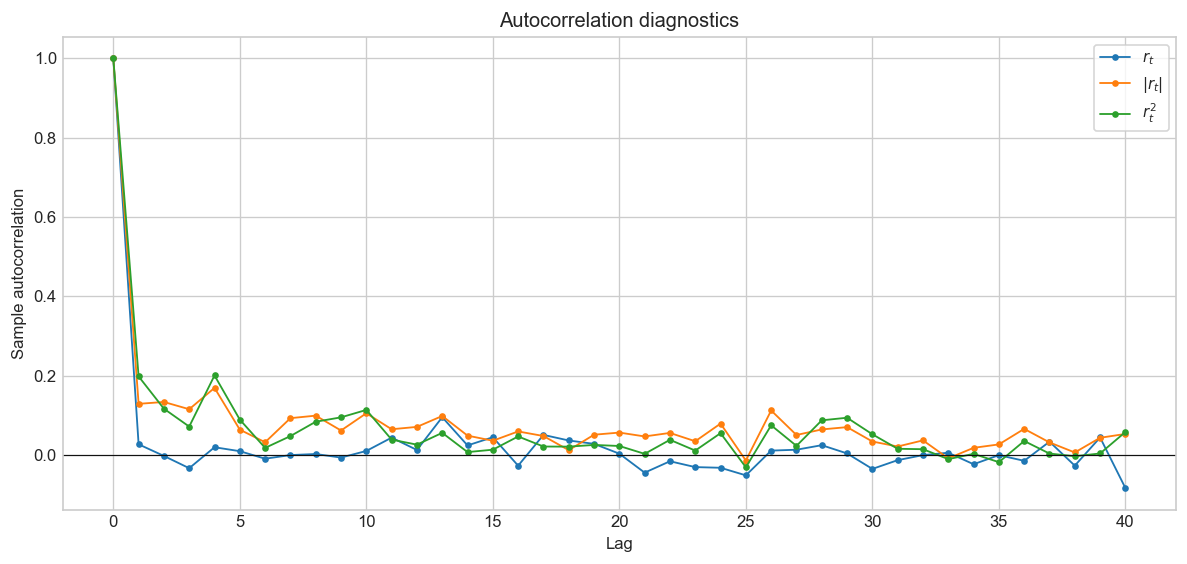

In [4]:
def autocorrelation(x, max_lag=40):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    out = np.empty(max_lag + 1)
    out[0] = 1.0
    for lag in range(1, max_lag + 1):
        out[lag] = np.dot(x[:-lag], x[lag:]) / denom
    return out


def sample_kurtosis(x):
    x = np.asarray(x, dtype=float)
    centered = x - x.mean()
    return np.mean(centered**4) / np.mean(centered**2) ** 2


diagnostics = [
    ("mean(r_t)", np.mean(r)),
    ("std(r_t)", np.std(r, ddof=1)),
    ("Pearson kurtosis of r_t", sample_kurtosis(r)),
    ("corr(r_t, r_{t-1})", np.corrcoef(r[1:], r[:-1])[0, 1]),
    ("corr(|r_t|, |r_{t-1}|)", np.corrcoef(np.abs(r[1:]), np.abs(r[:-1]))[0, 1]),
    ("corr(r_t^2, r_{t-1}^2)", np.corrcoef(r[1:] ** 2, r[:-1] ** 2)[0, 1]),
]

print("Baseline simulation diagnostics")
print("-" * 36)
for name, value in diagnostics:
    print(f"{name:<28} {value:>9.4f}")

max_lag = 40
lags = np.arange(max_lag + 1)
acf_r = autocorrelation(r, max_lag)
acf_abs_r = autocorrelation(np.abs(r), max_lag)
acf_sq_r = autocorrelation(r**2, max_lag)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(lags, acf_r, marker="o", markersize=3, linewidth=1.1, label="$r_t$")
ax.plot(lags, acf_abs_r, marker="o", markersize=3, linewidth=1.1, label="$|r_t|$")
ax.plot(lags, acf_sq_r, marker="o", markersize=3, linewidth=1.1, label="$r_t^2$")
ax.axhline(0, color="#111111", linewidth=0.7)
ax.set_title("Autocorrelation diagnostics")
ax.set_xlabel("Lag")
ax.set_ylabel("Sample autocorrelation")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "acf_returns_abs_squared.png")
plt.show()

The raw return autocorrelations are close to zero, which is consistent with the idea that financial returns are difficult to predict linearly. The absolute and squared return autocorrelations are more persistent because they inherit dependence from $h_t$. This is the volatility clustering effect that the SV model is designed to capture.

## 4. Persistence comparison

The parameter $\phi$ controls persistence in log-volatility. A lower value produces short-lived volatility shocks; a value near one produces long high-volatility and low-volatility regimes. The comparison below keeps $\mu$ and $\sigma_\eta$ fixed and varies only $\phi$.

saved: figures/sv_simulation/persistence_comparison.png


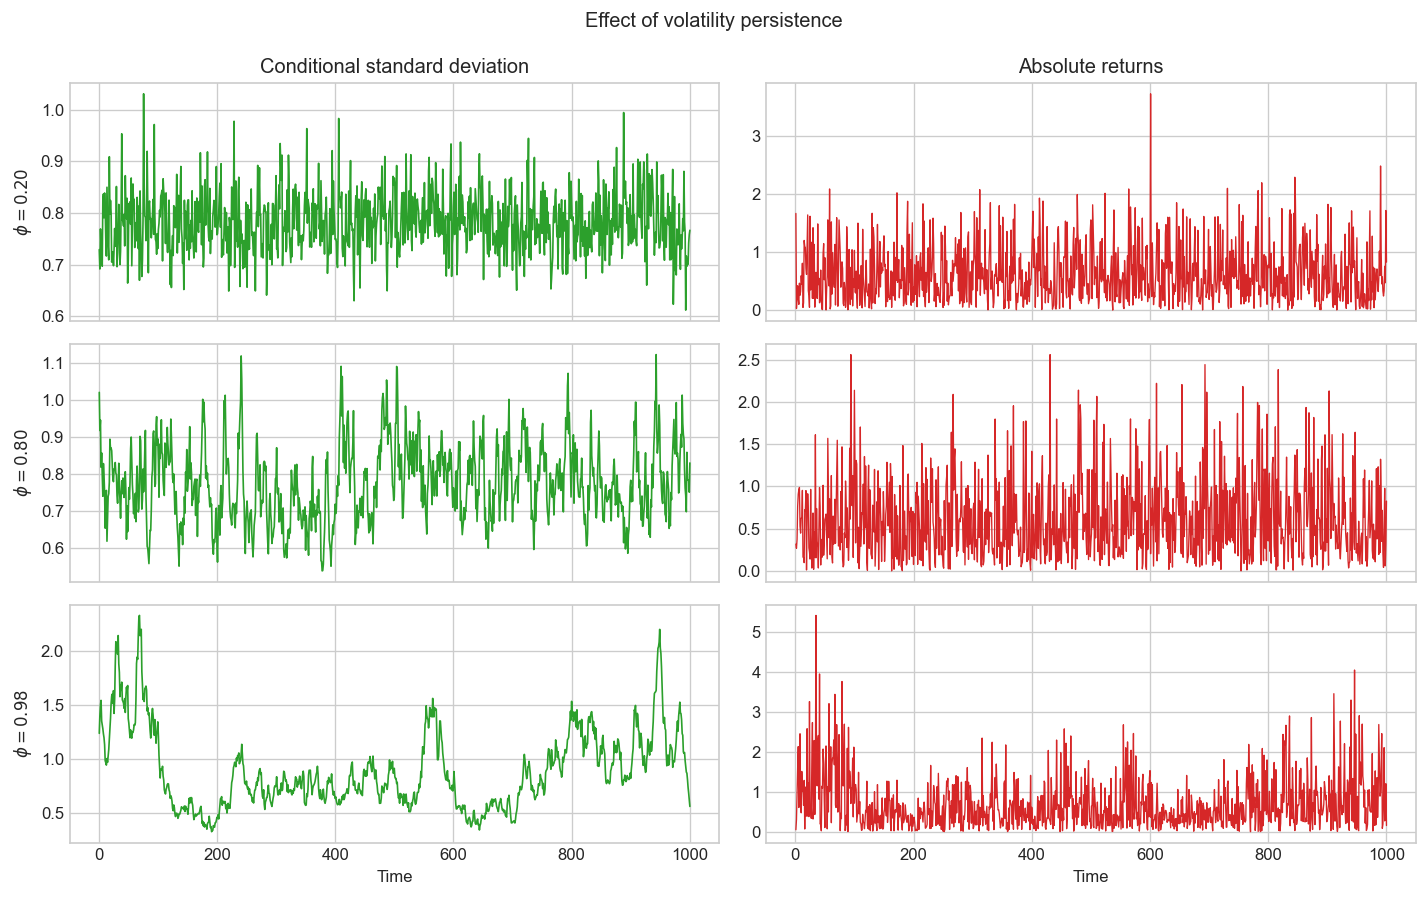

saved: figures/sv_simulation/persistence_acf_absolute_returns.png


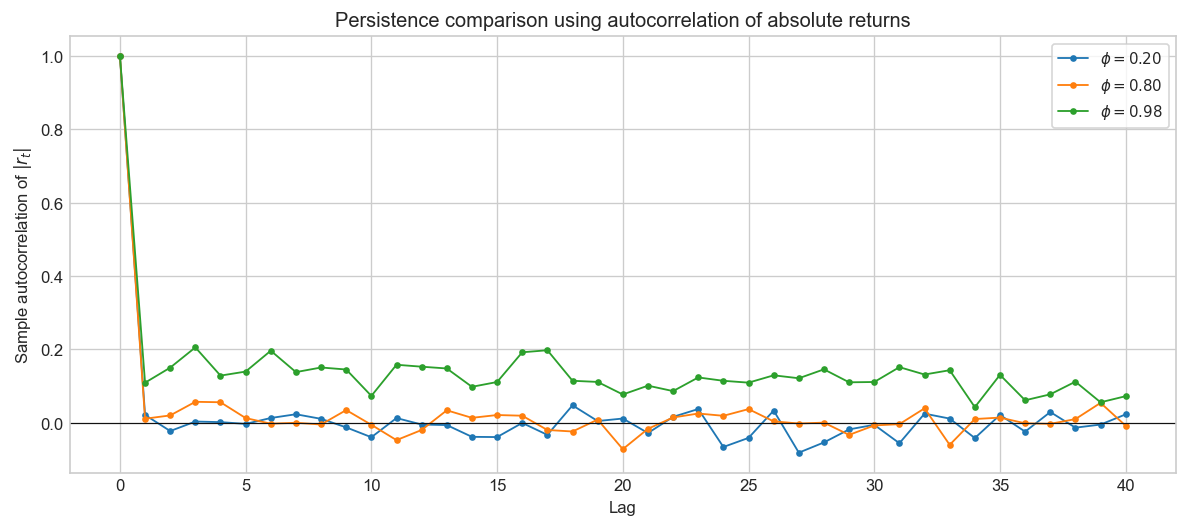

Autocorrelation of absolute returns by persistence level
--------------------------------------------------------
   phi      lag 1      lag 5     lag 10     lag 20
  0.20     0.0214    -0.0030    -0.0394     0.0116
  0.80     0.0111     0.0129    -0.0055    -0.0719
  0.98     0.1092     0.1395     0.0732     0.0771


In [5]:
phis = [0.20, 0.80, 0.98]
comparison = {
    phi: simulate_sv(T=1000, mu=-0.5, phi=phi, sigma_eta=0.15, seed=700 + int(phi * 100))
    for phi in phis
}

fig, axes = plt.subplots(len(phis), 2, figsize=(12, 7.5), sharex=True)

for row, phi in enumerate(phis):
    sim = comparison[phi]
    axes[row, 0].plot(sim["time"], sim["sigma"], color="#2ca02c", linewidth=1.0)
    axes[row, 0].set_ylabel(f"$\\phi={phi:.2f}$")
    axes[row, 0].set_title("Conditional standard deviation" if row == 0 else "")

    axes[row, 1].plot(sim["time"], np.abs(sim["r"]), color="#d62728", linewidth=0.8)
    axes[row, 1].set_title("Absolute returns" if row == 0 else "")

axes[-1, 0].set_xlabel("Time")
axes[-1, 1].set_xlabel("Time")
fig.suptitle("Effect of volatility persistence", y=0.99)
fig.tight_layout()
save_figure(fig, "persistence_comparison.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
for phi in phis:
    acf_abs = autocorrelation(np.abs(comparison[phi]["r"]), max_lag)
    ax.plot(lags, acf_abs, marker="o", markersize=3, linewidth=1.1, label=f"$\\phi={phi:.2f}$")

ax.axhline(0, color="#111111", linewidth=0.7)
ax.set_title("Persistence comparison using autocorrelation of absolute returns")
ax.set_xlabel("Lag")
ax.set_ylabel("Sample autocorrelation of $|r_t|$")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "persistence_acf_absolute_returns.png")
plt.show()

print("Autocorrelation of absolute returns by persistence level")
print("-" * 56)
print(f"{'phi':>6} {'lag 1':>10} {'lag 5':>10} {'lag 10':>10} {'lag 20':>10}")
for phi in phis:
    acf_abs = autocorrelation(np.abs(comparison[phi]["r"]), max_lag)
    print(f"{phi:>6.2f} {acf_abs[1]:>10.4f} {acf_abs[5]:>10.4f} {acf_abs[10]:>10.4f} {acf_abs[20]:>10.4f}")

## 5. Noisy volatility proxies

In real market data the econometrician observes $r_t$, not $h_t$. Absolute returns and log-squared returns are common rough proxies for volatility, but they are noisy because a large observed return can be caused either by high volatility or by a large standardized shock $\varepsilon_t$.

Volatility proxy diagnostics
------------------------------------------------
corr(h_t, |r_t|)                             0.3626
corr(h_t, log(r_t^2 + eps))                  0.2998
corr(h_t, 25-period mean |r_t|)              0.8526
corr(h_t, 25-period mean log(r_t^2 + eps))   0.7922


<>:30: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:30: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_27809/1637268978.py:30: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.plot(time, zscore(smoothed_log_squared), color="#9467bd", linewidth=1.0, alpha=0.85, label="25-period mean $\log(r_t^2)$")


saved: figures/sv_simulation/volatility_proxy_comparison.png


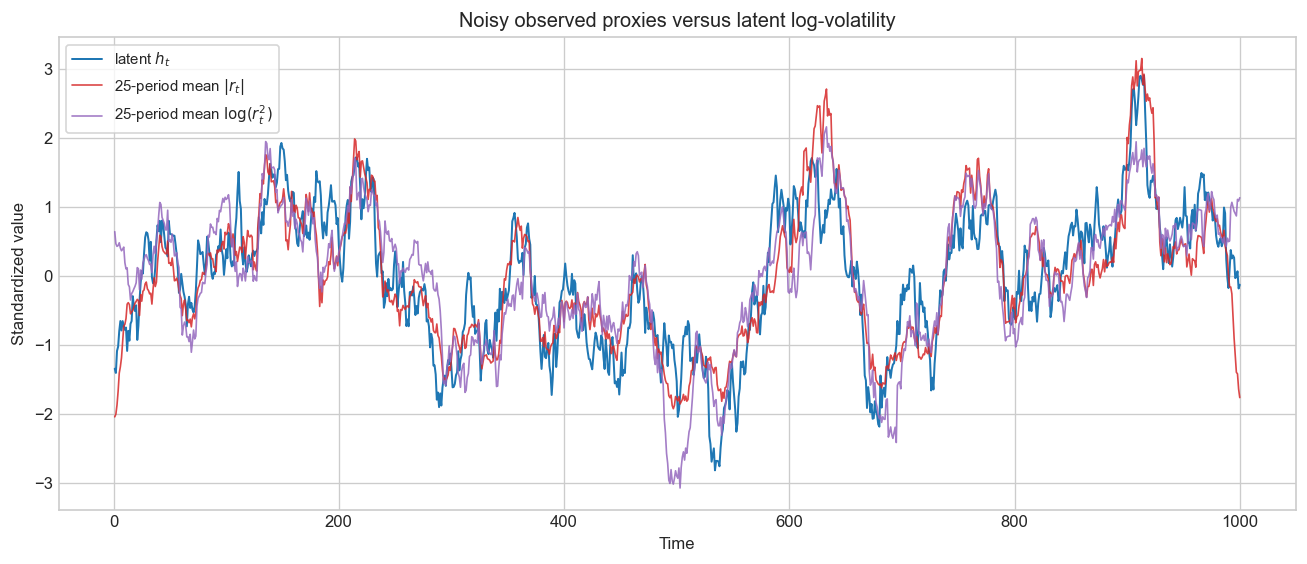

In [6]:
def moving_average(x, window=25):
    weights = np.ones(window) / window
    return np.convolve(x, weights, mode="same")


def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std(ddof=1)


log_squared_returns = np.log(r**2 + 1e-8)
smoothed_abs_returns = moving_average(np.abs(r), window=25)
smoothed_log_squared = moving_average(log_squared_returns, window=25)

proxy_diagnostics = [
    ("corr(h_t, |r_t|)", np.corrcoef(h, np.abs(r))[0, 1]),
    ("corr(h_t, log(r_t^2 + eps))", np.corrcoef(h, log_squared_returns)[0, 1]),
    ("corr(h_t, 25-period mean |r_t|)", np.corrcoef(h, smoothed_abs_returns)[0, 1]),
    ("corr(h_t, 25-period mean log(r_t^2 + eps))", np.corrcoef(h, smoothed_log_squared)[0, 1]),
]

print("Volatility proxy diagnostics")
print("-" * 48)
for name, value in proxy_diagnostics:
    print(f"{name:<42} {value:>8.4f}")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(time, zscore(h), color="#1f77b4", linewidth=1.2, label="latent $h_t$")
ax.plot(time, zscore(smoothed_abs_returns), color="#d62728", linewidth=1.0, alpha=0.85, label="25-period mean $|r_t|$")
ax.plot(time, zscore(smoothed_log_squared), color="#9467bd", linewidth=1.0, alpha=0.85, label="25-period mean $\log(r_t^2)$")
ax.set_title("Noisy observed proxies versus latent log-volatility")
ax.set_xlabel("Time")
ax.set_ylabel("Standardized value")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "volatility_proxy_comparison.png")
plt.show()

The proxy correlations are positive but imperfect. This is the reason the thesis treats volatility as a latent state and uses probabilistic inference rather than treating absolute or squared returns as observed volatility.

## 6. Known-parameter Bayesian filtering illustration

The following bootstrap particle filter is included only as a conceptual bridge to the Bayesian inference chapters. The parameters are treated as known and only the hidden path $h_{1:T}$ is filtered. A full Bayesian SV analysis would also assign priors to parameters such as $\mu$, $\phi$, and $\sigma_\eta$ and sample from their joint posterior with the latent states.

Known-parameter particle filter diagnostics
------------------------------------------------
RMSE of filtering mean for h_t:        0.4208
90% interval empirical coverage:       0.9010
Mean effective sample size:            3762.7
Estimated log marginal likelihood:   -1316.06
saved: figures/sv_simulation/particle_filter_latent_volatility.png


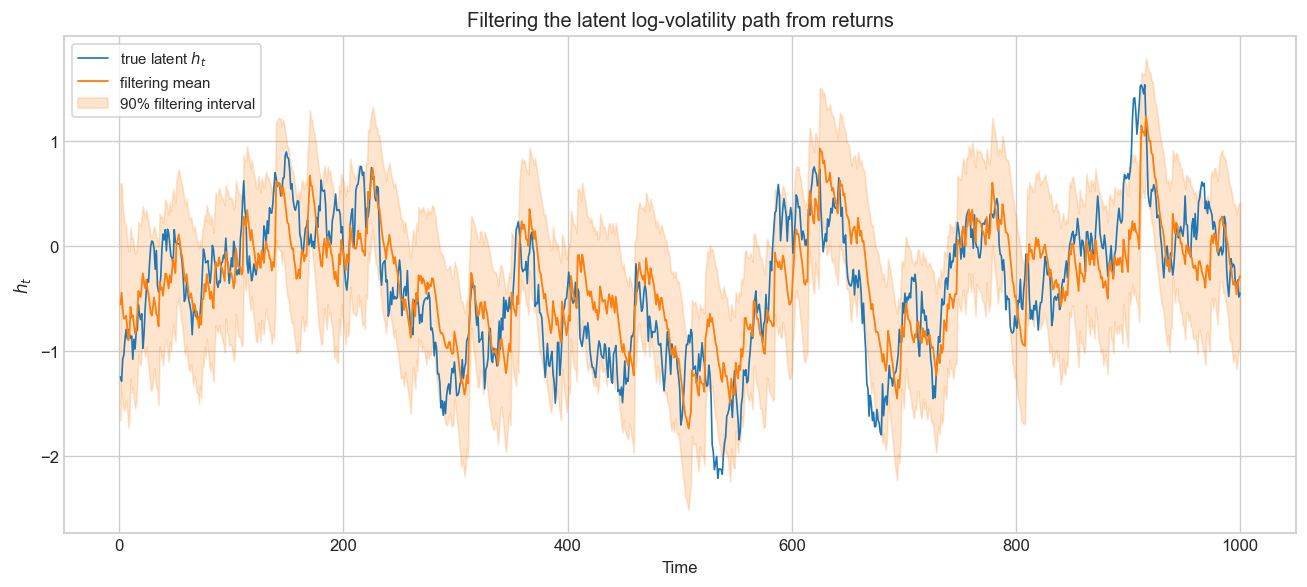

saved: figures/sv_simulation/particle_filter_ess.png


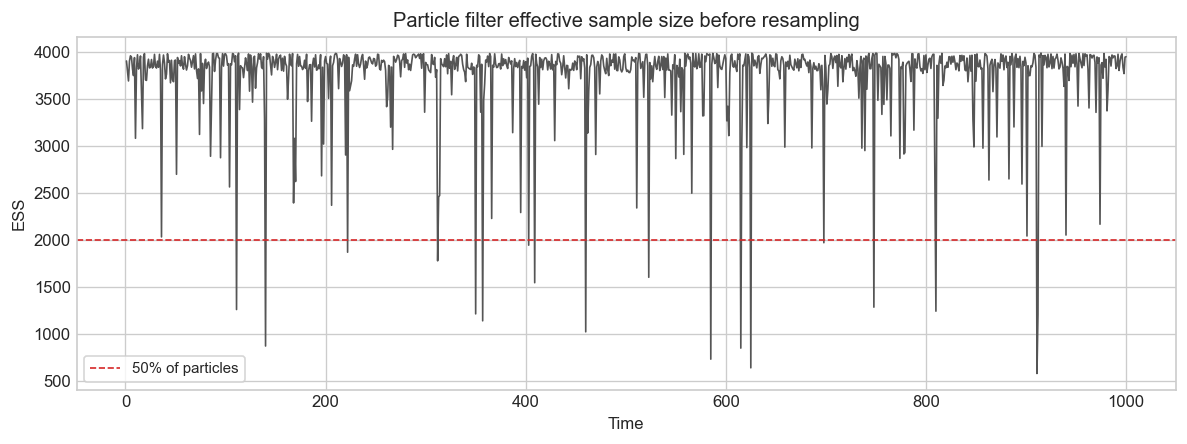

In [7]:
def return_loglikelihood(y, h_particles):
    """Log p(y_t | h_t) for y_t ~ N(0, exp(h_t))."""
    return -0.5 * (np.log(2 * np.pi) + h_particles + y**2 / np.exp(h_particles))


def weighted_quantile(values, quantiles, weights):
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)
    weights = np.asarray(weights)

    order = np.argsort(values)
    sorted_values = values[order]
    sorted_weights = weights[order]
    cdf = np.cumsum(sorted_weights)
    cdf = cdf / cdf[-1]
    return np.interp(quantiles, cdf, sorted_values)


def systematic_resample(weights, rng):
    n = len(weights)
    positions = (rng.random() + np.arange(n)) / n
    cumulative_sum = np.cumsum(weights)
    indices = np.empty(n, dtype=int)

    i = 0
    j = 0
    while i < n:
        if positions[i] < cumulative_sum[j]:
            indices[i] = j
            i += 1
        else:
            j += 1
    return indices


def bootstrap_particle_filter(r, mu=-0.5, phi=0.98, sigma_eta=0.15, n_particles=4000, seed=2024):
    rng = np.random.default_rng(seed)
    T = len(r)
    stationary_sd = sigma_eta / np.sqrt(1 - phi**2)
    particles = rng.normal(mu, stationary_sd, size=n_particles)

    means = np.empty(T)
    q05 = np.empty(T)
    q95 = np.empty(T)
    ess = np.empty(T)
    log_marginal_likelihood = 0.0

    for t, y in enumerate(r):
        if t > 0:
            innovations = rng.normal(0, sigma_eta, size=n_particles)
            particles = mu + phi * (particles - mu) + innovations

        logw = return_loglikelihood(y, particles)
        max_logw = np.max(logw)
        weights = np.exp(logw - max_logw)
        weight_sum = np.sum(weights)
        weights = weights / weight_sum

        log_marginal_likelihood += max_logw + np.log(weight_sum) - np.log(n_particles)
        means[t] = np.average(particles, weights=weights)
        q05[t], q95[t] = weighted_quantile(particles, [0.05, 0.95], weights)
        ess[t] = 1.0 / np.sum(weights**2)

        indices = systematic_resample(weights, rng)
        particles = particles[indices]

    return {
        "mean": means,
        "q05": q05,
        "q95": q95,
        "ess": ess,
        "log_marginal_likelihood": log_marginal_likelihood,
    }


pf = bootstrap_particle_filter(
    r,
    mu=baseline["params"]["mu"],
    phi=baseline["params"]["phi"],
    sigma_eta=baseline["params"]["sigma_eta"],
    n_particles=4000,
    seed=2024,
)

rmse = np.sqrt(np.mean((pf["mean"] - h) ** 2))
coverage = np.mean((h >= pf["q05"]) & (h <= pf["q95"]))

print("Known-parameter particle filter diagnostics")
print("-" * 48)
print(f"RMSE of filtering mean for h_t:      {rmse:>8.4f}")
print(f"90% interval empirical coverage:     {coverage:>8.4f}")
print(f"Mean effective sample size:          {np.mean(pf['ess']):>8.1f}")
print(f"Estimated log marginal likelihood:   {pf['log_marginal_likelihood']:>8.2f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(time, h, color="#1f77b4", linewidth=1.0, label="true latent $h_t$")
ax.plot(time, pf["mean"], color="#ff7f0e", linewidth=1.1, label="filtering mean")
ax.fill_between(time, pf["q05"], pf["q95"], color="#ff7f0e", alpha=0.20, label="90% filtering interval")
ax.set_title("Filtering the latent log-volatility path from returns")
ax.set_xlabel("Time")
ax.set_ylabel("$h_t$")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "particle_filter_latent_volatility.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(time, pf["ess"], color="#555555", linewidth=1.0)
ax.axhline(4000 / 2, color="#d62728", linestyle="--", linewidth=1.0, label="50% of particles")
ax.set_title("Particle filter effective sample size before resampling")
ax.set_xlabel("Time")
ax.set_ylabel("ESS")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "particle_filter_ess.png")
plt.show()

The filter tracks the broad movements of the simulated latent volatility, but the uncertainty band remains meaningful because a single return observation contains limited information about the current volatility state. This reproduces the key inference problem in SV models: the data inform volatility indirectly through the conditional return distribution.

## 7. Figure list for the appendix

The notebook saves publication-ready PNG files in `figures/sv_simulation/`. The four files named in the appendix draft are preserved, and the additional diagnostics can be included if the appendix needs a richer computational illustration.

In [8]:
print(f"Figures saved under: {FIGURE_DIR.resolve()}")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(f"- {path.name}")

Figures saved under: /Users/alexisgod/Desktop/thesis-code/src/figures/sv_simulation
- absolute_returns.png
- acf_returns_abs_squared.png
- baseline_sv_paths.png
- conditional_standard_deviation.png
- latent_log_volatility.png
- particle_filter_ess.png
- particle_filter_latent_volatility.png
- persistence_acf_absolute_returns.png
- persistence_comparison.png
- simulated_returns.png
- volatility_proxy_comparison.png
